In [1]:
import scanpy as sc
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import colors
import seaborn as sb
from os import mkdir
import os
import warnings
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data
import random

In [2]:
sc.set_figure_params(dpi=60, 
                     dpi_save=300, 
                     color_map= 'viridis_r')
plt.rcParams['figure.figsize']=(6,6) #rescale figures
plt.rcParams['grid.alpha']=0
sc.settings.verbosity = 3
sc.logging.print_header()

scanpy==1.9.5 anndata==0.10.2 umap==0.5.4 numpy==1.26.1 scipy==1.11.3 pandas==2.1.1 scikit-learn==1.3.1 statsmodels==0.14.0 pynndescent==0.5.10


In [3]:
#print shape of the matrix 
def shape(adata):
    print ('In the dataset there are:')
    print (f'{adata.obs.shape[0]} cells')
    print (f'{adata.var.shape[0]} genes')
    
## creating a boxplot to show the data distribution
def range_values_in_dataset (plot_title='Non normalized dataset'):
    tmp1=pd.DataFrame(adata.X)
    uniques=np.unique (tmp1)
    outliers_annotations = dict(markerfacecolor='g', marker='D', markersize=4, alpha=0.1,)
    box_annotations= dict(linewidth=1, color='blue', alpha=0.9 , facecolor='teal' )
    plt.boxplot (uniques, patch_artist=True, 
                 flierprops=outliers_annotations, 
                 boxprops= box_annotations )
    plt.ylabel('Unique range of values in the dataset ')
    plt.title (plot_title) ## you can notice it because the range is large
    plt.tick_params(labelbottom=False, bottom=False)
    sb.displot(uniques, kind="kde", legend=False)
    plt.tick_params(labelleft=False, left=False, )
    del uniques, tmp1

#Check how many genes form the ones we want to analyze remain after filtering
def genes_in_dataset (genes_list, dataset,):
    global found_genes
    global no_found_genes
    found_genes=[]
    no_found_genes=[]
    for gene in genes_list:
        if gene in dataset.raw.var_names:
            found_genes.append (gene)
        else:
            no_found_genes.append (gene, )
    #return found_genes, no_found_genes
    print (f'We found {len (found_genes)} out of {len(ALL_GENES)}')
    print (f'These genes are not in the datset: {no_found_genes}')

In [4]:
#Genes that we are analyzing
ALL_GENES=['oc', 'Optix', 'tll', 'Lim1', 'scro', 'Gsc', 'Rx','hh', 'wg', 'ci', 'mirr', 'ems', 'ey','erm','slp1','slp2'
         , 'Dbx', 'Ptx1', 'ths', 'pyr', 'htl', 'fd102C', 'so', 'Six4','Lim3', 'eya']
genes_homeobox=['lab', 'pb', 'Dfd', 'Scr', 'Antp', 'Ubx', 'abd-A', 'Abd-B' ] 


In [5]:
%%time
#Reading the filtered dataset
data_file='./3_tribolium_neuroblast_dataset/2_tribolium_neuroblasts_normalized_and_log_dataset.h5ad'
adata = sc.read_h5ad(data_file)


CPU times: user 186 ms, sys: 712 ms, total: 898 ms
Wall time: 896 ms


In [6]:
annotations = pd.read_csv("../integration_dataset_and_annotation/cell_annotation_brain_NBs_1_Drosophila_and_Tribolium_label_transfer.csv", index_col=0)
annotations.columns = ['cell_types', 'dataset']
annotations = annotations[annotations['dataset'] != 'drosophila']
annotations = annotations.rename_axis('cell_id')
annotations.drop('dataset', axis=1, inplace=True)
#annotations

adata.obs['cell_types'] = (
    annotations.reindex(adata.obs_names)
    .fillna('Unknown'))

#Removed unwanted cells in brain neuroblasts
cell_types_to_remove = [
    'Midline_NBs', 
    'PCGs', 
    'Sensory NBs', 
    'plasmatocytes/embryonic hemocytes/macrophages', 
    'Mesodermal/muscle progenitors'
]
# Filter out the cells
adata = adata[~adata.obs['cell_types'].isin(cell_types_to_remove)].copy()
adata.obs['cell_types'].value_counts()

cell_types
Unknown                           36963
GMC                                8391
NBs I                              3863
NBs II/INPs/newborn neurons_1?     2522
NBs II/INPs/newborn neurons_2?     1344
NBs II/INPs                         777
Name: count, dtype: int64

In [7]:
####Removing cells that do not have NBs gene markers
genes_of_interest= ['tGFP', 'ase', 'wor', 'dpn', 'pnt', 'pros']

# keep only genes that actually exist in the dataset
existing_genes= [g for g in genes_of_interest if g in adata.var_names]

print("Found genes:", existing_genes)

# boolean mask: cells expressing ANY of the genes (>0)
mask= np.any(adata[:, existing_genes].X.toarray() > 0, axis=1)

# filter AnnData
adata_filtered= adata[mask].copy()

adata= adata_filtered
del adata_filtered

Found genes: ['tGFP', 'ase', 'wor', 'dpn', 'pnt', 'pros']


In [8]:
adata.obs_names_make_unique

<bound method AnnData.obs_names_make_unique of AnnData object with n_obs × n_vars = 34885 × 14455
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm', 'hox', 'cell_types'
    var: 'feature_types', 'genome', 'is_TF', 'original_TC_ids', 'ribo', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'scrublet'
    layers: 'counts'>

In [9]:
adata


AnnData object with n_obs × n_vars = 34885 × 14455
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm', 'hox', 'cell_types'
    var: 'feature_types', 'genome', 'is_TF', 'original_TC_ids', 'ribo', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'scrublet'
    layers: 'counts'

In [10]:
adata_TF = adata[:, adata.var['is_TF'] == True].copy()
adata= adata_TF
adata

AnnData object with n_obs × n_vars = 34885 × 840
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm', 'hox', 'cell_types'
    var: 'feature_types', 'genome', 'is_TF', 'original_TC_ids', 'ribo', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'scrublet'
    layers: 'counts'

In [11]:
# Keep only genes NOT in genes_homeobox
adata_filtered = adata[:, ~adata.var_names.isin(genes_homeobox)].copy()
adata= adata_filtered
adata

AnnData object with n_obs × n_vars = 34885 × 832
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm', 'hox', 'cell_types'
    var: 'feature_types', 'genome', 'is_TF', 'original_TC_ids', 'ribo', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'scrublet'
    layers: 'counts'

In [12]:
##Recalling the raw data, that was saved originally in the layers['counts']
## This is necessary for the DE analysis
adata.X= adata.layers['counts']
adata.raw = adata

In [13]:
adata

AnnData object with n_obs × n_vars = 34885 × 832
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_counts', 'norm', 'hox', 'cell_types'
    var: 'feature_types', 'genome', 'is_TF', 'original_TC_ids', 'ribo', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'scrublet'
    layers: 'counts'

In [14]:
#sc.pl.highest_expr_genes(adata, n_top=20, )

In [15]:
adata.obs_names_make_unique()

In [16]:
# Create an empty DataFrame to store the sums for each replicate
sums_per_replicate_df = pd.DataFrame(index=adata.var_names)

replicates_n = 10


for neuroblast in adata.obs.hox.unique():
    #check the two conditions: Hox and No_hox
    sample_subset = adata[adata.obs['hox'] == neuroblast]

    #Divide the indices (cells) of each condition in equal parts.
    #This indices are use to create pseudo replicates
    indices = list(sample_subset.obs_names)
    random.shuffle(indices)
    indices = np.array_split(np.array(indices), replicates_n)

    for i, pseudo_rep in enumerate(indices):
        #Subset the pseudoreplicates
        pseudo_rep_data = sample_subset[pseudo_rep, :].copy()
        pseudo_rep_data.obs['replicate'] = i

        # Sum the values for each gene across cells in the replicate
        sum_per_replicate = np.sum(pseudo_rep_data.X, axis=0).T

        # Store the sums in the DataFrame with gene names as indices
        sums_per_replicate_df[f'{str(neuroblast)}_{i+1}'] = sum_per_replicate

sums_per_replicate_df

,Hox_1,Hox_2,Hox_3,Hox_4,Hox_5,Hox_6,Hox_7,Hox_8,Hox_9,Hox_10,No_hox_1,No_hox_2,No_hox_3,No_hox_4,No_hox_5,No_hox_6,No_hox_7,No_hox_8,No_hox_9,No_hox_10
gene_names,,,,,,,,,,,,,,,,,,,,
Hey,902.0,882.0,815.0,845.0,854.0,779.0,777.0,787.0,843.0,775.0,173.0,226.0,227.0,220.0,208.0,164.0,197.0,207.0,282.0,216.0
Klf15,4.0,7.0,3.0,3.0,4.0,5.0,8.0,6.0,4.0,7.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
erm,35.0,39.0,45.0,36.0,36.0,56.0,38.0,45.0,45.0,38.0,26.0,33.0,34.0,29.0,36.0,29.0,38.0,35.0,40.0,33.0
CG10600,1024.0,916.0,841.0,904.0,903.0,922.0,930.0,829.0,884.0,983.0,208.0,204.0,167.0,184.0,208.0,176.0,199.0,203.0,192.0,205.0
ewg,2175.0,2134.0,2138.0,2155.0,2137.0,2118.0,2107.0,1989.0,2101.0,2143.0,450.0,450.0,435.0,453.0,451.0,446.0,485.0,431.0,469.0,447.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TC031898,7.0,5.0,13.0,13.0,15.0,18.0,17.0,18.0,9.0,22.0,4.0,4.0,4.0,2.0,3.0,0.0,0.0,2.0,4.0,2.0
TC031788,14.0,10.0,10.0,10.0,6.0,13.0,19.0,12.0,14.0,13.0,5.0,2.0,1.0,2.0,1.0,2.0,3.0,2.0,4.0,3.0
HLH54F,80.0,115.0,48.0,137.0,67.0,53.0,77.0,127.0,98.0,119.0,17.0,7.0,8.0,10.0,10.0,10.0,22.0,8.0,10.0,29.0


In [17]:
counts= sums_per_replicate_df.T
counts

gene_names,Hey,Klf15,erm,CG10600,ewg,TC001633,vri,onecut,TC016055,BORCS6,...,grn,sqz,TC004259,TC031009,TC005199,TC031898,TC031788,HLH54F,TC002340,CG10984
Hox_1,902.0,4.0,35.0,1024.0,2175.0,196.0,52.0,1871.0,337.0,119.0,...,4282.0,3104.0,10646.0,14.0,75.0,7.0,14.0,80.0,1100.0,727.0
Hox_2,882.0,7.0,39.0,916.0,2134.0,167.0,59.0,1832.0,387.0,121.0,...,3732.0,2611.0,10559.0,11.0,86.0,5.0,10.0,115.0,1041.0,758.0
Hox_3,815.0,3.0,45.0,841.0,2138.0,170.0,47.0,1845.0,348.0,123.0,...,4285.0,2474.0,10410.0,15.0,79.0,13.0,10.0,48.0,1029.0,702.0
Hox_4,845.0,3.0,36.0,904.0,2155.0,177.0,55.0,1927.0,369.0,125.0,...,3980.0,2705.0,10673.0,14.0,65.0,13.0,10.0,137.0,1077.0,736.0
Hox_5,854.0,4.0,36.0,903.0,2137.0,162.0,66.0,1812.0,350.0,147.0,...,4104.0,2414.0,10544.0,16.0,68.0,15.0,6.0,67.0,1058.0,753.0
Hox_6,779.0,5.0,56.0,922.0,2118.0,177.0,49.0,1850.0,366.0,131.0,...,4424.0,2621.0,10758.0,16.0,90.0,18.0,13.0,53.0,1102.0,700.0
Hox_7,777.0,8.0,38.0,930.0,2107.0,223.0,65.0,1840.0,326.0,117.0,...,3744.0,2336.0,10272.0,17.0,89.0,17.0,19.0,77.0,994.0,721.0
Hox_8,787.0,6.0,45.0,829.0,1989.0,163.0,46.0,1742.0,296.0,121.0,...,3971.0,2552.0,10306.0,16.0,75.0,18.0,12.0,127.0,1091.0,667.0
Hox_9,843.0,4.0,45.0,884.0,2101.0,198.0,38.0,1871.0,343.0,138.0,...,3855.0,2874.0,10513.0,18.0,78.0,9.0,14.0,98.0,1107.0,737.0
Hox_10,775.0,7.0,38.0,983.0,2143.0,181.0,59.0,1879.0,356.0,101.0,...,3788.0,2481.0,10655.0,24.0,97.0,22.0,13.0,119.0,1024.0,691.0


In [18]:
metadata= pd.DataFrame(counts.index)
metadata.rename(columns={0: "sample"}, inplace=True)
metadata['condition'] = metadata['sample'].apply(lambda x: 'No_hox' if 'No' in x else x.split('_')[0])
metadata.set_index('sample', inplace=True)
metadata['replicate'] = metadata.index.str.extract('(\d+)', expand=False)
metadata

,condition,replicate
sample,,
Hox_1,Hox,1
Hox_2,Hox,2
Hox_3,Hox,3
Hox_4,Hox,4
Hox_5,Hox,5
Hox_6,Hox,6
Hox_7,Hox,7
Hox_8,Hox,8
Hox_9,Hox,9


In [19]:
dds= DeseqDataSet( counts=counts, metadata= metadata, design_factors= 'condition')

/home/beetle/miniconda3/envs/pydeseq/lib/python3.11/site-packages/pydeseq2/dds.py:257: UserWarning: Some factor levels in the design contain underscores ('_').
                    They will be converted to hyphens ('-').
  self.obsm["design_matrix"] = build_design_matrix(


In [20]:
dds

AnnData object with n_obs × n_vars = 20 × 832
    obs: 'condition', 'replicate'
    obsm: 'design_matrix'

In [21]:
sc.pp.filter_genes(dds, min_cells=1)

filtered out 1 genes that are detected in less than 1 cells


In [22]:
dds.deseq2()

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.15 seconds.

Fitting dispersion trend curve...
... done in 0.13 seconds.

Fitting MAP dispersions...
... done in 0.16 seconds.

Fitting LFCs...
... done in 0.12 seconds.

Refitting 0 outliers.



In [23]:
dds

AnnData object with n_obs × n_vars = 20 × 831
    obs: 'condition', 'replicate'
    var: 'n_cells'
    uns: 'trend_coeffs', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', 'size_factors', 'replaceable'
    varm: 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', '_normed_means', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced'
    layers: 'normed_counts', '_mu_hat', '_mu_LFC', '_hat_diagonals', 'cooks'

computing PCA
    with n_comps=19
    finished (0:00:00)


/home/beetle/miniconda3/envs/pydeseq/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/beetle/miniconda3/envs/pydeseq/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


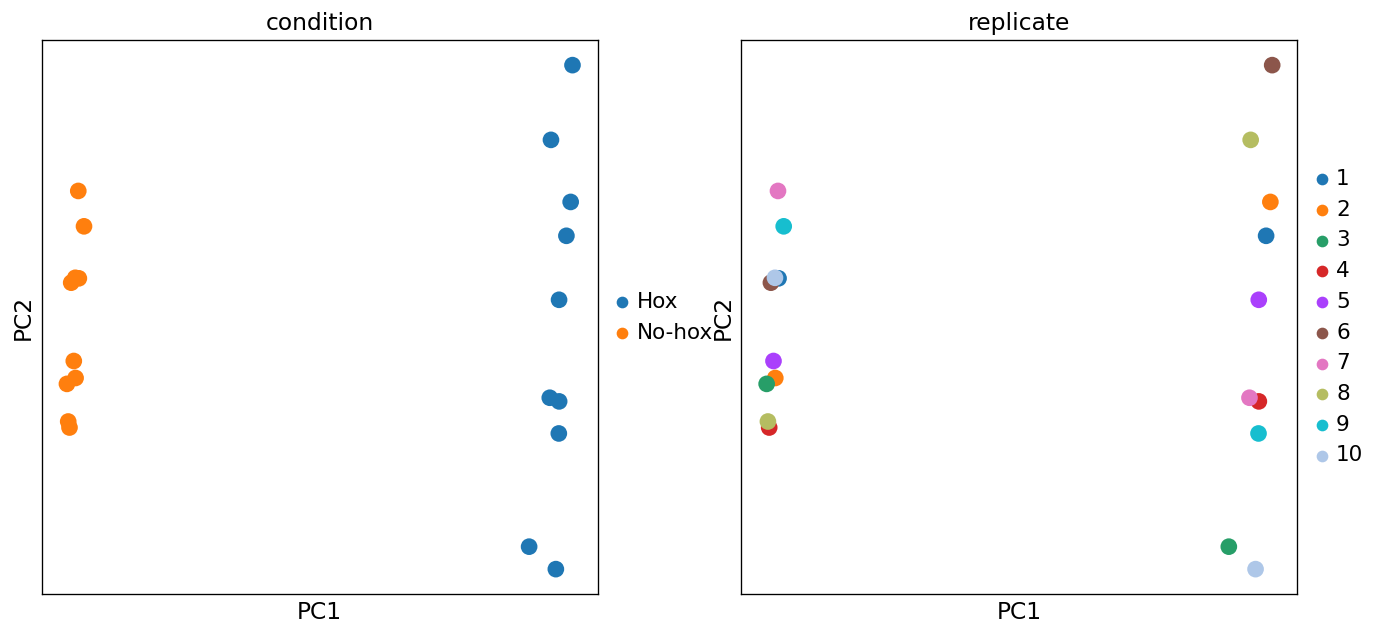

/home/beetle/miniconda3/envs/pydeseq/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:324: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = ax.scatter(
/home/beetle/miniconda3/envs/pydeseq/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:324: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = ax.scatter(


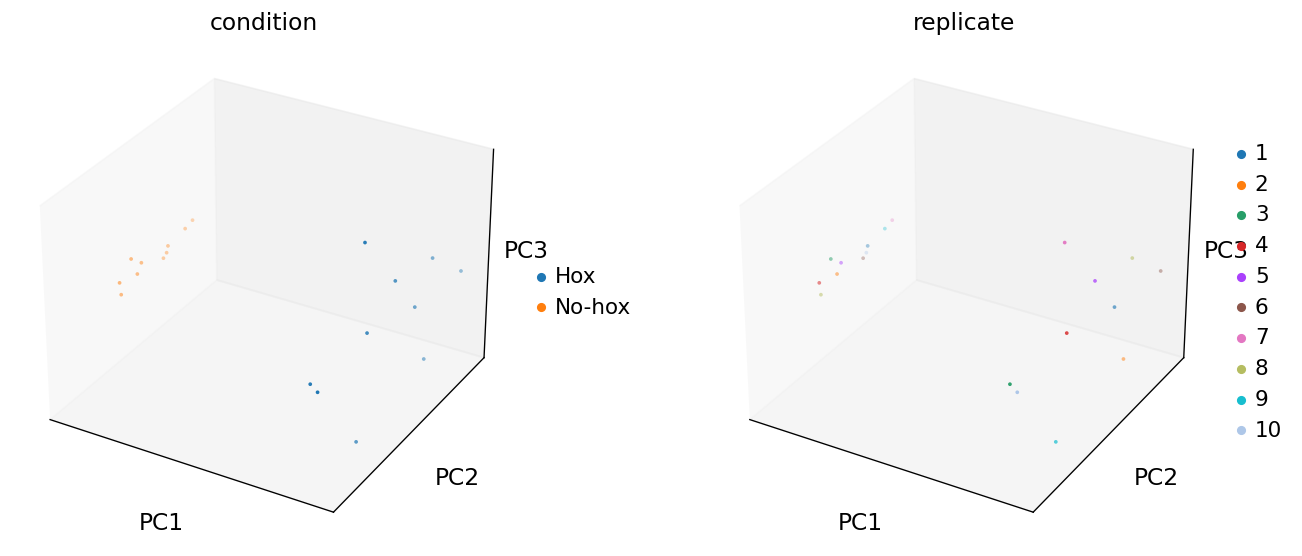

In [24]:
sc.tl.pca(dds)
sc.pl.pca(dds, color= ['condition', 'replicate'], size=400, projection='2d',)
sc.pl.pca(dds, color= ['condition', 'replicate'], size=200, projection='3d' ,)

In [25]:
stat_res= DeseqStats(dds, n_cpus=10, contrast= ('condition', 'No-hox', 'Hox') )
stat_res.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: condition No-hox vs Hox


... done in 1.34 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_names,,,,,,
Hey,418.752371,0.290114,0.056646,5.121547,3.030393e-07,4.169402e-06
Klf15,1.919744,-0.611887,0.612240,-0.999423,3.175898e-01,5.545660e-01
erm,45.662678,1.942540,0.118662,16.370355,3.113925e-60,8.283040e-58
CG10600,420.218728,0.022696,0.045631,0.497383,6.189192e-01,7.978958e-01
ewg,975.618902,0.023001,0.026442,0.869864,3.843748e-01,6.221725e-01
...,...,...,...,...,...,...
TC031898,5.827000,-0.205184,0.380043,-0.539897,5.892680e-01,7.759668e-01
TC031788,5.472882,-0.022475,0.344604,-0.065219,9.479995e-01,9.727998e-01
HLH54F,35.281347,-0.558080,0.263200,-2.120364,3.397532e-02,1.238005e-01


In [26]:
de= stat_res.results_df
de

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_names,,,,,,
Hey,418.752371,0.290114,0.056646,5.121547,3.030393e-07,4.169402e-06
Klf15,1.919744,-0.611887,0.612240,-0.999423,3.175898e-01,5.545660e-01
erm,45.662678,1.942540,0.118662,16.370355,3.113925e-60,8.283040e-58
CG10600,420.218728,0.022696,0.045631,0.497383,6.189192e-01,7.978958e-01
ewg,975.618902,0.023001,0.026442,0.869864,3.843748e-01,6.221725e-01
...,...,...,...,...,...,...
TC031898,5.827000,-0.205184,0.380043,-0.539897,5.892680e-01,7.759668e-01
TC031788,5.472882,-0.022475,0.344604,-0.065219,9.479995e-01,9.727998e-01
HLH54F,35.281347,-0.558080,0.263200,-2.120364,3.397532e-02,1.238005e-01


In [27]:
de.sort_values('stat', ascending=False)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_names,,,,,,
tll,48.761035,2.168772,0.118832,18.250694,2.042965e-74,1.630286e-71
oc,346.892069,1.123771,0.062103,18.095332,3.468472e-73,1.383920e-70
erm,45.662678,1.942540,0.118662,16.370355,3.113925e-60,8.283040e-58
toy,549.488558,0.991439,0.064891,15.278512,1.063409e-52,2.121500e-50
Optix,167.684180,1.600780,0.112725,14.200806,9.056532e-46,1.445423e-43
...,...,...,...,...,...,...
TC000916,174.430875,-0.704276,0.078501,-8.971590,2.922650e-19,1.794058e-17
hth,2791.611702,-0.222913,0.024052,-9.267884,1.898748e-20,1.377456e-18
TC005342,608.916252,-0.723075,0.071694,-10.085515,6.402884e-24,5.677224e-22


In [28]:
#This is just to get rid of genes with low impact, it is mostl arbitrary
de=de[de.baseMean >= 10]

In [29]:
sigs= de[(de.padj < 0.05) & (abs(de.log2FoldChange) > 0.05)]
sigs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_names,,,,,,
Hey,418.752371,0.290114,0.056646,5.121547,3.030393e-07,4.169402e-06
erm,45.662678,1.942540,0.118662,16.370355,3.113925e-60,8.283040e-58
TC014168,276.323397,0.198206,0.050062,3.959199,7.520150e-05,6.667867e-04
fd96Ca,52.976224,-0.495213,0.146271,-3.385586,7.102656e-04,4.886138e-03
HGTX,192.493191,-0.569708,0.083122,-6.853840,7.189331e-12,1.509760e-10
...,...,...,...,...,...,...
TC001789,28.372339,-0.638237,0.167780,-3.803999,1.423787e-04,1.195981e-03
Phf5a,671.754737,0.146945,0.031046,4.733186,2.210228e-06,2.628823e-05
Fer3,18.113952,-0.720171,0.224018,-3.214789,1.305406e-03,8.333710e-03


In [30]:
dds.layers['log1p']= np.log1p(dds.layers['normed_counts'])
dds

AnnData object with n_obs × n_vars = 20 × 831
    obs: 'condition', 'replicate'
    var: 'n_cells'
    uns: 'trend_coeffs', '_squared_logres', 'prior_disp_var', 'pca', 'condition_colors', 'replicate_colors'
    obsm: 'design_matrix', 'size_factors', 'replaceable', 'X_pca'
    varm: 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', '_normed_means', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'PCs'
    layers: 'normed_counts', '_mu_hat', '_mu_LFC', '_hat_diagonals', 'cooks', 'log1p'

In [31]:
dds_sigs= dds[:, sigs.index]
dds_sigs


View of AnnData object with n_obs × n_vars = 20 × 172
    obs: 'condition', 'replicate'
    var: 'n_cells'
    uns: 'trend_coeffs', '_squared_logres', 'prior_disp_var', 'pca', 'condition_colors', 'replicate_colors'
    obsm: 'design_matrix', 'size_factors', 'replaceable', 'X_pca'
    varm: 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', '_normed_means', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', 'LFC', '_LFC_converged', 'replaced', 'PCs'
    layers: 'normed_counts', '_mu_hat', '_mu_LFC', '_hat_diagonals', 'cooks', 'log1p'

In [32]:
grapher=  pd.DataFrame(dds_sigs.layers['log1p'].T,
                        index=dds_sigs.var_names, columns=dds_sigs.obs_names)
grapher

sample,Hox_1,Hox_2,Hox_3,Hox_4,Hox_5,Hox_6,Hox_7,Hox_8,Hox_9,Hox_10,No_hox_1,No_hox_2,No_hox_3,No_hox_4,No_hox_5,No_hox_6,No_hox_7,No_hox_8,No_hox_9,No_hox_10
gene_names,,,,,,,,,,,,,,,,,,,,
Hey,6.012147,5.980444,5.950712,5.958063,5.965178,5.864104,5.886404,5.906288,5.954205,5.859250,5.926427,6.174409,6.225875,6.165999,6.107549,5.922681,6.080301,6.138285,6.371202,6.153234
erm,2.821773,2.915011,3.097779,2.858710,2.855448,3.267450,2.921147,3.088632,3.068890,2.897837,4.046204,4.262485,4.338449,4.153401,4.364109,4.202500,4.444209,4.371466,4.428467,4.286187
TC014168,5.536964,5.652860,5.571295,5.502490,5.556905,5.602208,5.543837,5.523468,5.491646,5.553049,5.784180,5.675207,5.750890,5.625909,5.768125,5.691049,5.610657,5.516961,5.672670,5.782857
fd96Ca,4.203740,4.214557,3.964556,4.092784,4.197636,3.967288,4.134670,4.199215,4.339753,4.049429,3.209571,4.135215,4.247338,3.882134,3.115727,4.056470,3.465617,3.241203,3.840346,4.088569
HGTX,5.432041,5.342554,5.578423,5.493139,5.508308,5.398100,5.437102,5.342687,5.526725,5.333054,4.967107,4.785527,4.995392,5.025355,4.746792,5.130131,4.913058,5.178505,5.286532,5.302606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TC001789,3.397977,3.605303,3.590380,3.408666,3.714679,3.600390,3.325252,3.655960,3.623712,3.705755,2.468425,3.352368,3.536542,2.780212,3.015282,3.065128,2.929171,3.402221,3.400564,3.022933
Phf5a,6.440854,6.447942,6.446928,6.456924,6.463453,6.446918,6.446480,6.480381,6.485783,6.472601,6.657853,6.483420,6.504226,6.468915,6.556102,6.602235,6.651172,6.544637,6.500528,6.620704
Fer3,3.101264,3.170439,3.198615,2.804919,3.108520,3.196268,3.357954,3.514057,2.980323,2.992655,2.468425,2.249519,2.291805,2.468247,3.015282,1.712284,3.141569,2.667144,3.168457,2.785425


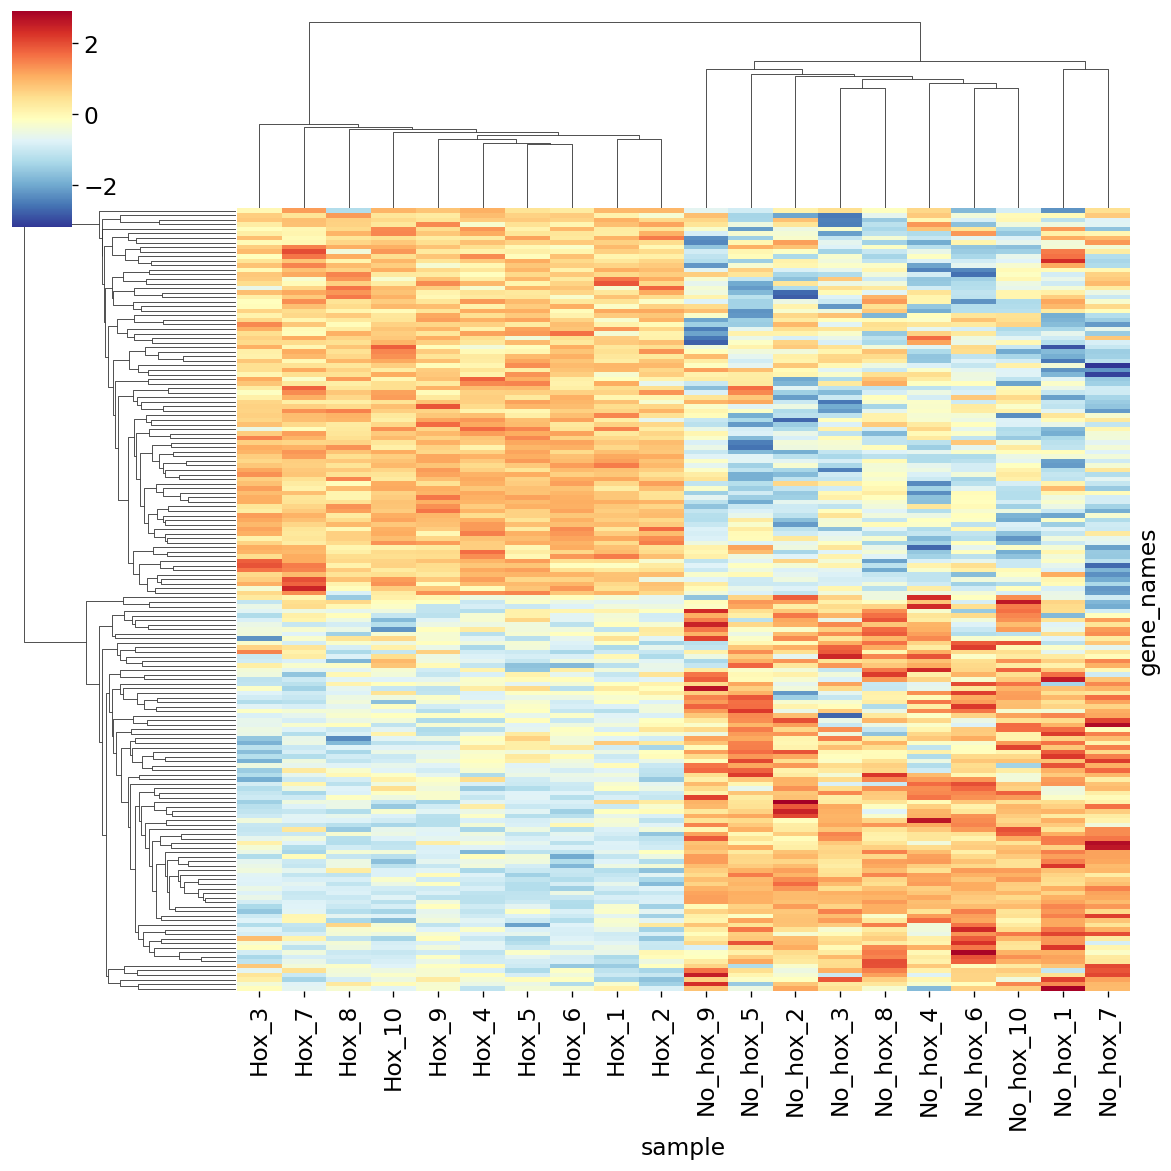

In [33]:
sb.clustermap(grapher, z_score=0,cmap= 'RdYlBu_r', yticklabels=False)

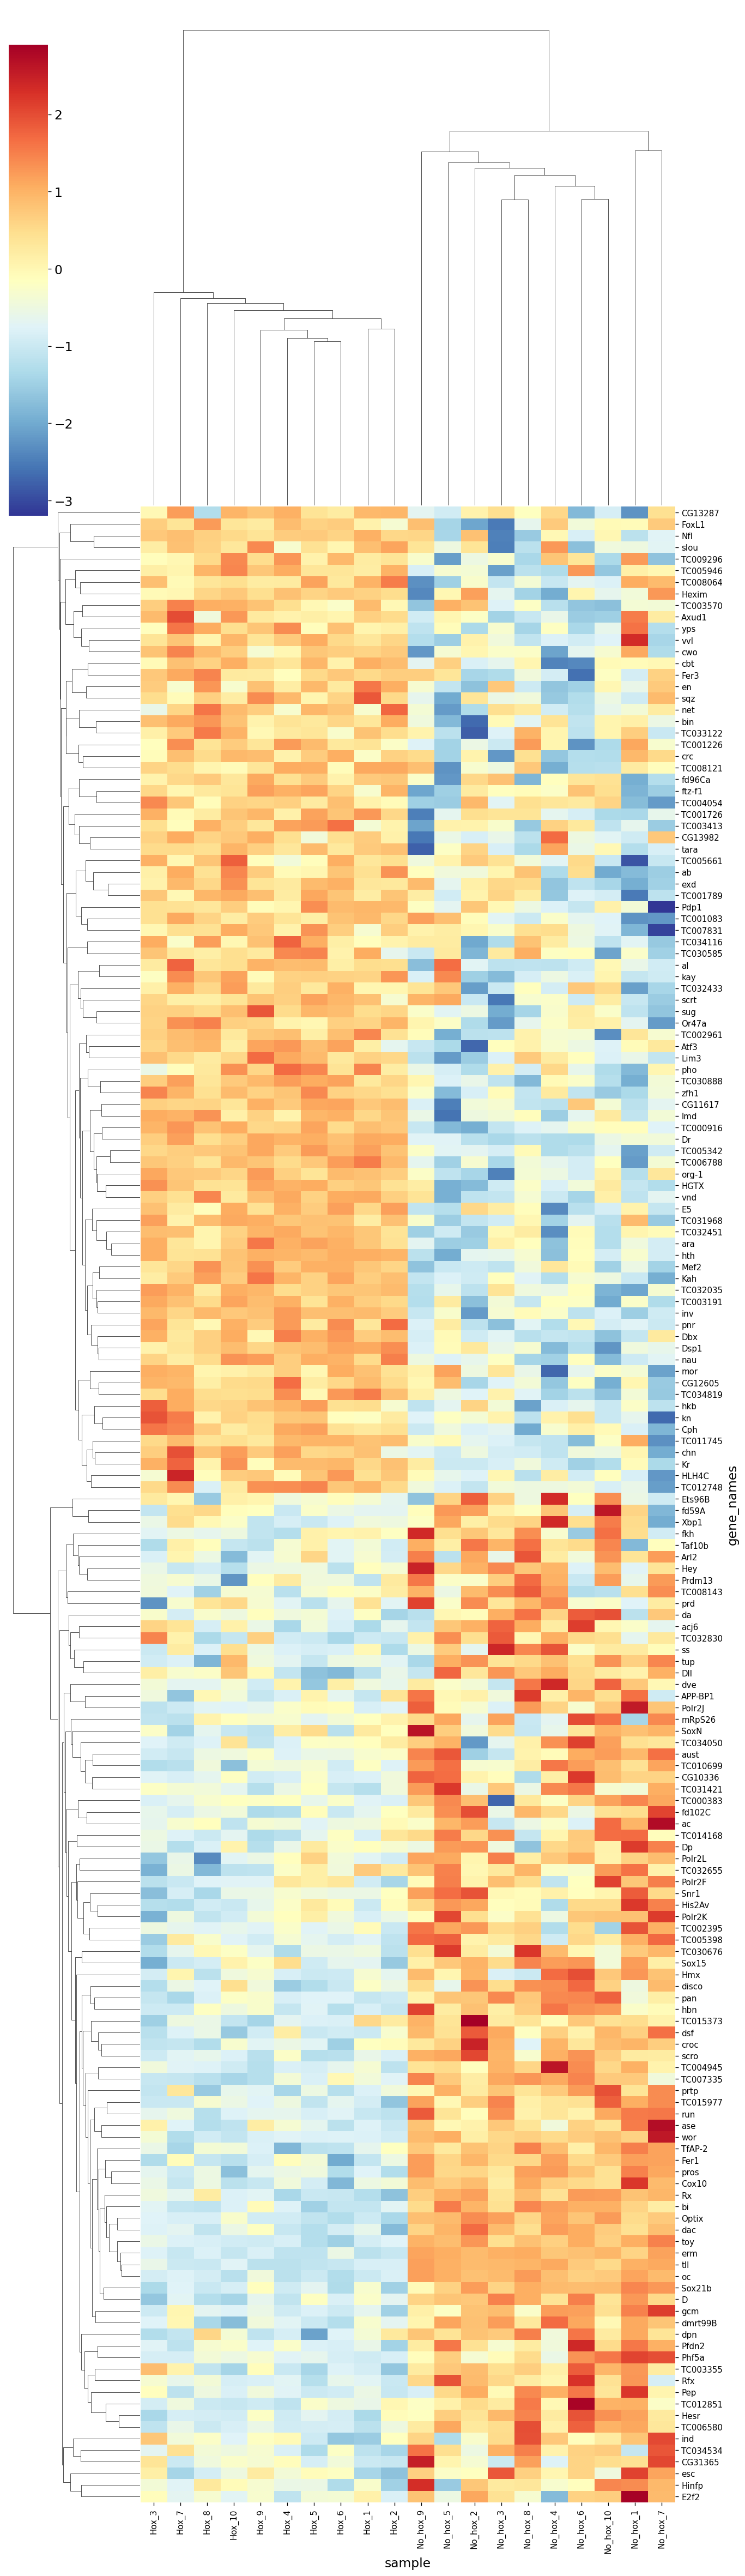

In [34]:

# Create the clustermap
g = sb.clustermap(
    grapher,
    z_score=0,
    cmap='RdYlBu_r',
    figsize=(12, 40),       # adjust width/height as needed
    yticklabels=True,
    xticklabels=True,)

g.ax_heatmap.tick_params(labelsize=9)
g.fig.savefig("figures/heatmap_DE_TFs_genes_tribolium_without_hox.pdf", dpi=300, )


In [35]:
# Reordered row and column indices (as numpy arrays)
row_order = g.dendrogram_row.reordered_ind
col_order = g.dendrogram_col.reordered_ind

# Reorder the DataFrame according to the clustering order
ordered_data = grapher.iloc[row_order, col_order]

# Show the first few rows
print(ordered_data.head())

# Save to CSV if you want
ordered_data.to_csv('3_tribolium_neuroblast_dataset/4_TFs_without_Hox_DE_ordered_as_inthe_heatmapplot_tribolium.csv')

sample         Hox_3     Hox_7     Hox_8    Hox_10     Hox_9     Hox_4  \
gene_names                                                               
CG13287     4.503077  4.734180  4.266741  4.689229  4.653559  4.697568   
FoxL1       4.433016  4.359050  4.568769  4.352289  4.327791  4.484975   
NfI         4.025113  4.073658  3.990202  3.941636  3.889273  4.005211   
slou        4.222531  4.388179  4.329994  4.254780  4.533706  4.092784   
TC009296    5.574865  5.586309  5.637497  5.725942  5.633320  5.713200   

sample         Hox_5     Hox_6     Hox_1     Hox_2  No_hox_9  No_hox_5  \
gene_names                                                               
CG13287     4.579576  4.546628  4.682441  4.685630  4.377802  4.336302   
FoxL1       4.423242  4.440852  4.293999  4.180937  4.476689  3.923251   
NfI         4.018316  3.967288  4.133886  3.951336  3.965598  3.206998   
slou        4.276522  4.181488  4.393663  4.469926  4.268052  4.043569   
TC009296    5.596518  5.679018  5.609

In [36]:
#In case writing to save the file throws err0r run this lines
filtered_data = dds.uns['trend_coeffs']
# Convert values to strings
dds.uns['trend_coeffs']= {key: str(value) for key, value in filtered_data.items()}

### saving PyDEseq files
animal='tribolium'
gene_types= 'TFs_without_Hox'
folder= '3_tribolium_neuroblast_dataset'

pydesed_file= f'4_{gene_types}_PyDEseq_analysis_{animal}.h5ad' #This file is going to be used for the the downstream analysis
dds.write(pydesed_file)
os.system (f'mv {pydesed_file} {folder}')

0

In [37]:
#updated heatmap plot

# Shared TFs
shared_tfs = ['CG5516', 'Dll', 'Fer1', 'Hmx', 'Optix', 'Rx', 'TfAP-2', 'Xbp1', 'bi', 'croc', 'dac', 'disco', 'dmrt99B', 'erm', 'fd102C', 'fkh', 'hbn', 'oc', 'pan', 'scro', 'srp', 'tll', 'toy', 'tup', 'wor',
'CG13287', 'CTCF', 'Dr', 'Dsp1', 'Fer3', 'HGTX', 'Kr', 'Oli', 'Poxn', 'Ptx1', 'Top1', 'ab', 'chn', 'eg', 'ems', 'en', 'fd96Ca', 'ftz', 'grh', 'gsb', 'gsb-n', 'hkb', 'inv', 'mid', 'mirr', 'pho', 'scrt', 'slou', 'slp1', 'su(Hw)', 'tara', 'trh', 'vnd', 'vvl']



sss = pd.read_csv('3_tribolium_neuroblast_dataset/4_TFs_without_Hox_DE_ordered_as_inthe_heatmapplot_tribolium.csv')
sss.drop(columns=['gene_originals', 'Nbs_type'], inplace=True)

# Keep only numeric columns for clustermap
data_numeric = sss.select_dtypes(include=['float', 'int'])
row_labels = sss['gene_names']

# Create the clustermap
ss = sb.clustermap(
    data_numeric,
    z_score=0,            # normalize rows (genes)
    cmap='RdYlBu_r',
    figsize=(12, 40),
    yticklabels=row_labels,
    xticklabels=True
)

# Change tick label colors for shared TFs
for label in ss.ax_heatmap.get_yticklabels():
    if label.get_text() in shared_tfs:
        label.set_color('green')

ss.ax_heatmap.tick_params(labelsize=9)
ss.fig.savefig("figures/heatmap_DE_TFs_genes_tribolium_without_hox_updated.pdf", dpi=300)
plt.show()



KeyError: "['gene_originals', 'Nbs_type'] not found in axis"